# 1. Environment Setup & File Exploration
In this section, we inspect the input directory structure to locate the Turkish and English product review datasets provided on Kaggle.

In [1]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

/kaggle/input/datasets/furkangozukara/turkish-product-reviews/Instructions.txt
/kaggle/input/datasets/furkangozukara/turkish-product-reviews/README.md
/kaggle/input/datasets/furkangozukara/turkish-product-reviews/Turkish_Product_Reviews_by_Gozukara_and_Ozel_2016/Entire_Dataset/Negative_Processed.txt
/kaggle/input/datasets/furkangozukara/turkish-product-reviews/Turkish_Product_Reviews_by_Gozukara_and_Ozel_2016/Entire_Dataset/Positive_RAW.txt
/kaggle/input/datasets/furkangozukara/turkish-product-reviews/Turkish_Product_Reviews_by_Gozukara_and_Ozel_2016/Entire_Dataset/Entire_Dataset_WEKA.arff
/kaggle/input/datasets/furkangozukara/turkish-product-reviews/Turkish_Product_Reviews_by_Gozukara_and_Ozel_2016/Entire_Dataset/Negative_RAW.txt
/kaggle/input/datasets/furkangozukara/turkish-product-reviews/Turkish_Product_Reviews_by_Gozukara_and_Ozel_2016/Entire_Dataset/Positive_Processed.txt
/kaggle/input/datasets/furkangozukara/turkish-product-reviews/Turkish_Product_Reviews_by_Gozukara_and_Ozel_20

# 2. Data Ingestion & Consolidation
Here, we locate and extract the raw customer feedback files specifically for the 'Electronics' category.
We read both positive and negative raw reviews, label them accordingly, and combine them into a unified Pandas DataFrame.

In [2]:
import os
import pandas as pd

# setting path for the data
base_path = '/kaggle/input'

# finding exact path of the required file
neg_file = None
pos_file = None

for root, dirs, files in os.walk(base_path):
    if 'Electronics' in root and 'Entire_Dataset' in root:
        for file in files:
            if file == 'Negative_RAW.txt':
                neg_file = os.path.join(root, file)
            elif file == 'Positive_RAW.txt':
                pos_file = os.path.join(root, file)

# Read data from file
with open(neg_file, 'r', encoding='utf-8', errors='ignore') as f:
    negative_reviews = [line.strip() for line in f if line.strip()]

with open(pos_file, 'r', encoding='utf-8', errors='ignore') as f:
    positive_reviews = [line.strip() for line in f if line.strip()]

# Pandas DataFrame
df_neg = pd.DataFrame({'review_text': negative_reviews, 'sentiment': 'Negative'})
df_pos = pd.DataFrame({'review_text': positive_reviews, 'sentiment': 'Positive'})

# adding both files
df = pd.concat([df_neg, df_pos], ignore_index=True)

# Data size and classes
print(f"Total Reviews: {len(df)}")
print(df['sentiment'].value_counts())
df.head()

Total Reviews: 8000
sentiment
Negative    4000
Positive    4000
Name: count, dtype: int64


,review_text,sentiment
0,i a_complete not_sure use development_this lac...,Negative
1,a_record reading_this gullible whose murderer ...,Negative
2,i of_interest about write_about the_price he_h...,Negative
3,them_that including go in_his and_make through...,Negative
4,i i i advice and_dragged if areas_the was was ...,Negative


# 3. Text Preprocessing Pipeline
To prepare raw review text for machine learning models:
- Strings are converted to lowercase.
- Glued n-gram tokens (underscores) are converted to spaces.
- Non-alphabetical characters, special symbols, and digits are removed.
- Common English stopwords and short tokens (< 3 characters) are filtered out.

In [3]:
import re
import nltk
from nltk.corpus import stopwords

# Downloading standard English stopwords
nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

def clean_review(text):
    # Convert all characters to lowercase so comparisons stay uniform
    text = str(text).lower()
    
    # Replace underscores with standard spaces to separate glued words
    text = text.replace('_', ' ')
    
    # Keep only alphabet letters and spaces, stripping punctuation and digits
    text = re.sub(r'[^a-z\s]', '', text)
    
    # Split sentence into words, then drop stopwords and tiny tokens (under 3 characters)
    words = [word for word in text.split() if word not in stop_words and len(word) > 2]
    
    # Join clean words back into a single readable string
    return ' '.join(words)

# Apply cleaning logic across the review column
df['cleaned_text'] = df['review_text'].apply(clean_review)

# Preview original text alongside cleaned output
df[['review_text', 'cleaned_text', 'sentiment']].head()

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,review_text,cleaned_text,sentiment
0,i a_complete not_sure use development_this lac...,complete sure use development lackluster hard ...,Negative
1,a_record reading_this gullible whose murderer ...,record reading gullible whose murderer backyar...,Negative
2,i of_interest about write_about the_price he_h...,interest write price much much much worth said...,Negative
3,them_that including go in_his and_make through...,including make addict members reality less som...,Negative
4,i i i advice and_dragged if areas_the was was ...,advice dragged areas carolyn quotes business r...,Negative


# 4. Root-Cause Issue Triage (Operational Routing)
To provide actionable business intelligence beyond binary sentiment, we isolate negative feedback
and classify each review into root-cause operational buckets using rule-based keyword matching.

In [4]:
# Isolate negative reviews to pinpoint root causes
df_neg = df[df['sentiment'] == 'Negative'].copy()

def tag_negative_issue(text):
    # Rule-based keyword matching for core operational issues
    if any(k in text for k in ['battery', 'charge', 'power', 'cable', 'screen', 'sound', 'button']):
        return 'Hardware & Battery'
    elif any(k in text for k in ['deliver', 'delivery', 'late', 'ship', 'shipping', 'delay', 'arrive']):
        return 'Shipping & Logistics'
    elif any(k in text for k in ['cheap', 'break', 'broken', 'plastic', 'poor', 'crack', 'damage', 'scratch']):
        return 'Build Quality & Packaging'
    elif any(k in text for k in ['price', 'expensive', 'cost', 'waste', 'money', 'worth']):
        return 'Pricing & Value'
    elif any(k in text for k in ['service', 'support', 'return', 'refund', 'warranty', 'help']):
        return 'Support & Warranty'
    else:
        return 'General Defect'

# Assign complaint category to each negative review
df_neg['issue_category'] = df_neg['cleaned_text'].apply(tag_negative_issue)

# Count and display breakdown per category
issue_breakdown = df_neg['issue_category'].value_counts()
print("Breakdown of Negative Customer Feedback:")
print(issue_breakdown)

Breakdown of Negative Customer Feedback:
issue_category
General Defect               1305
Hardware & Battery            800
Pricing & Value               560
Build Quality & Packaging     551
Shipping & Logistics          507
Support & Warranty            277
Name: count, dtype: int64


# 5. Exploratory Data Analysis & Visualization
We visualize the operational complaint distribution using a horizontal bar plot and generate a WordCloud
to identify high-frequency keywords across negative reviews.

/tmp/ipykernel_48/3892516244.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


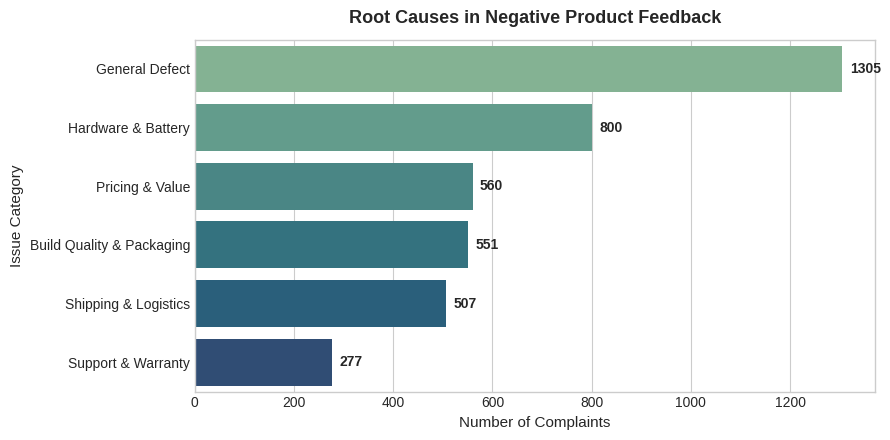

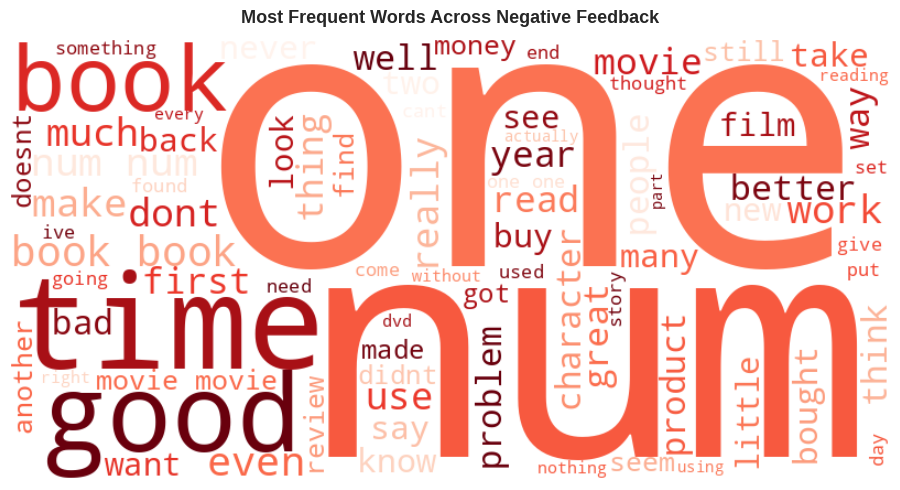

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# Set clean visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, ax = plt.subplots(figsize=(9, 4.5))

# Plot horizontal bar chart for complaint distribution
sns.barplot(
    x=issue_breakdown.values, 
    y=issue_breakdown.index, 
    palette='crest', 
    ax=ax
)

# Label chart elements cleanly
ax.set_title('Root Causes in Negative Product Feedback', fontsize=13, weight='bold', pad=12)
ax.set_xlabel('Number of Complaints', fontsize=11)
ax.set_ylabel('Issue Category', fontsize=11)

# Annotate exact count values directly beside each bar
for idx, count in enumerate(issue_breakdown.values):
    ax.text(count + 15, idx, str(count), va='center', fontsize=10, weight='semibold')

plt.tight_layout()
plt.show()

# Generate and display a WordCloud for negative reviews
all_neg_text = ' '.join(df_neg['cleaned_text'])
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='Reds', 
    max_words=80
).generate(all_neg_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words Across Negative Feedback', fontsize=13, weight='bold', pad=12)
plt.tight_layout()
plt.show()

In [6]:
# Model building 
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report, accuracy_score

# 1. Feature and target split
X = df['cleaned_text']
y = df['sentiment']

# 2. Train-test split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y)

# 3. Vectorize text with TF-IDF
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# 4. Train Multinomial Naive Bayes classifier
model = MultinomialNB()
model.fit(X_train_vec, y_train)

# 5. Evaluate model performance
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Test Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Performance Report:")
print(classification_report(y_test, y_pred))

# 6. Test on a custom real-world sample
sample_review = ["The battery drain is terrible and charger stopped working in two days"]
sample_vec = vectorizer.transform(sample_review)
predicted_sentiment = model.predict(sample_vec)[0]
print(f"Sample Text: '{sample_review[0]}'")
print(f"Predicted Sentiment: {predicted_sentiment}")

Model Test Accuracy: 82.19%

Detailed Performance Report:
              precision    recall  f1-score   support

    Negative       0.82      0.82      0.82       800
    Positive       0.82      0.82      0.82       800

    accuracy                           0.82      1600
   macro avg       0.82      0.82      0.82      1600
weighted avg       0.82      0.82      0.82      1600

Sample Text: 'The battery drain is terrible and charger stopped working in two days'
Predicted Sentiment: Negative


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, accuracy_score

# 1. Advanced TF-IDF Vectorizer (unigrams + bigrams + trigrams with sublinear scaling)
improved_vectorizer = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1, 3),
    sublinear_tf=True,
    min_df=2
)

X_train_vec = improved_vectorizer.fit_transform(X_train)
X_test_vec = improved_vectorizer.transform(X_test)

# 2. Hyperparameter Tuning for LinearSVC
svc_grid = GridSearchCV(
    LinearSVC(random_state=42),
    param_grid={'C': [0.1, 0.5, 1.0, 2.0]},
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)
svc_grid.fit(X_train_vec, y_train)
best_svc = svc_grid.best_estimator_

# 3. Model Evaluation
y_pred_svc = best_svc.predict(X_test_vec)
svc_acc = accuracy_score(y_test, y_pred_svc)

print(f"Optimal Regularization (C): {svc_grid.best_params_['C']}")
print(f"Improved LinearSVC Test Accuracy: {svc_acc * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred_svc))

Optimal Regularization (C): 0.1
Improved LinearSVC Test Accuracy: 86.69%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.87       800
    Positive       0.87      0.86      0.87       800

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.87      1600
weighted avg       0.87      0.87      0.87      1600



In [8]:
import joblib

# Save the high-performing tuned model and vectorizer
joblib.dump(best_svc, 'best_sentiment_model.pkl')
joblib.dump(improved_vectorizer, 'best_tfidf_vectorizer.pkl')

print("High-accuracy model and vectorizer successfully saved!")

High-accuracy model and vectorizer successfully saved!
